In [95]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

data = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

In [96]:
# ensures random sequence is deterministic and reproducible
random_seed = 42

# Drop features that are not relevant for classification
drop_features = ['FILENAME', 'URL', 'Domain']

# Features and target
X = data.drop(columns=drop_features + ['label'])
y = data['label']

# Confirm the unique classes in the target variable (should be 0 and 1 for binary classification)
print(y.unique())

[1 0]


In [97]:
# Print example of 1 Legitimate URL
print(data[data['label'] == 1].sample(1))

# Print example of 1 Phishing URL
print(data[data['label'] == 0].sample(1))

          FILENAME                                   URL  URLLength  \
101124  582498.txt  https://www.theempoweredprovider.com         35   

                              Domain  DomainLength  IsDomainIP  TLD  \
101124  www.theempoweredprovider.com            28           0  com   

        URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  Pay  \
101124               100.0                   1.0           0.522907  ...    1   

        Crypto  HasCopyrightInfo  NoOfImage  NoOfCSS  NoOfJS  NoOfSelfRef  \
101124       0                 1         15       15      34            3   

        NoOfEmptyRef  NoOfExternalRef  label  
101124             0               61      1  

[1 rows x 56 columns]
           FILENAME                                   URL  URLLength  \
183306  8025910.txt  https://amazon-vbvhjhy.sexidude.com/         35   

                             Domain  DomainLength  IsDomainIP  TLD  \
183306  amazon-vbvhjhy.sexidude.com            27           0  c

In [98]:
# Convert TLD to numeric using LabelEncoder
url_features = ['URLLength', 'DomainLength', 'IsDomainIP', 'TLD', 'TLDLength', 'NoOfSubDomain',
                'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
                'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL']

le = LabelEncoder()
X['TLD'] = le.fit_transform(X['TLD'])

print(len(url_features))

# Train/test split with only URL features
X_train, X_test, y_train, y_test = train_test_split(X[url_features], y, test_size=0.2, random_state=random_seed, stratify=y)

# Print train test split and class distribution
print("Train set class distribution:")
print(y_train.value_counts(normalize=True))
print("Train set size:", len(y_train))
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True))
print("Test set size:", len(y_test))

15
Train set class distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64
Train set size: 188636

Test set class distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64
Test set size: 47159


In [99]:
# 200 trees in forest
# n_jobs = -1 uses all CPU cores
rf = RandomForestClassifier(
    n_estimators = 50,
    random_state = random_seed,
    n_jobs = -1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9966072223753685


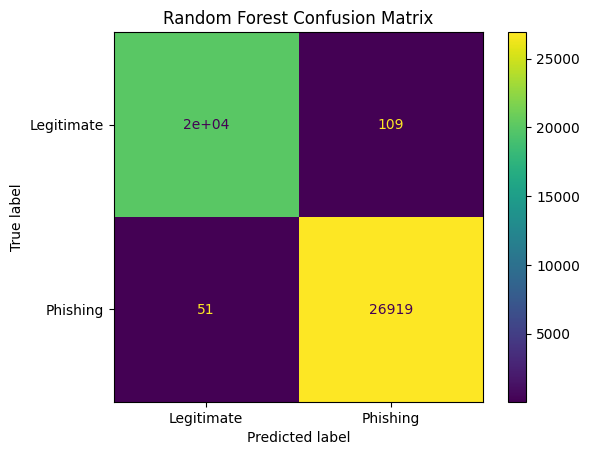

In [100]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

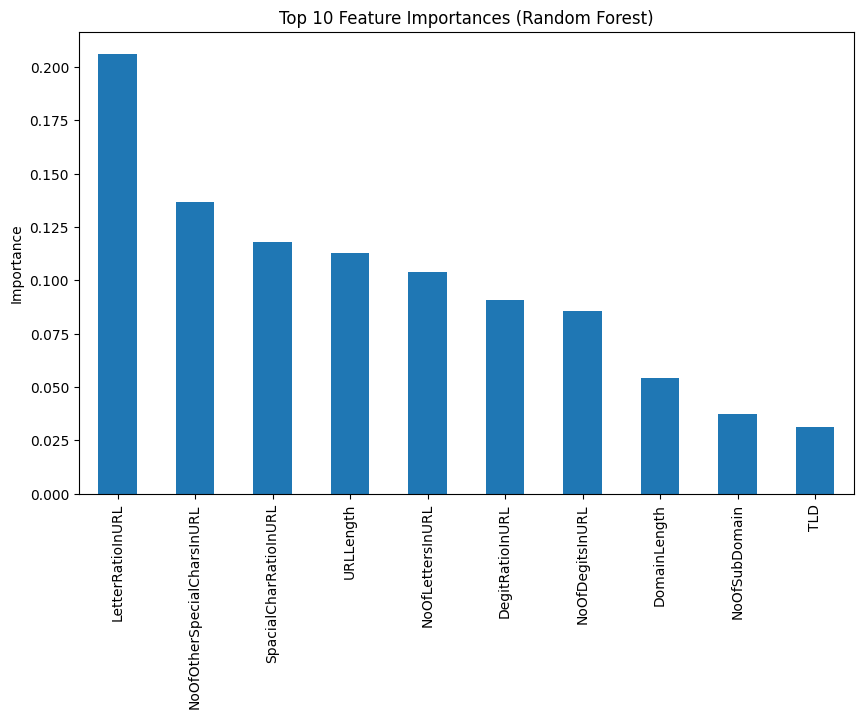

In [101]:
# 10 most important features for Random Forest
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='bar')
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

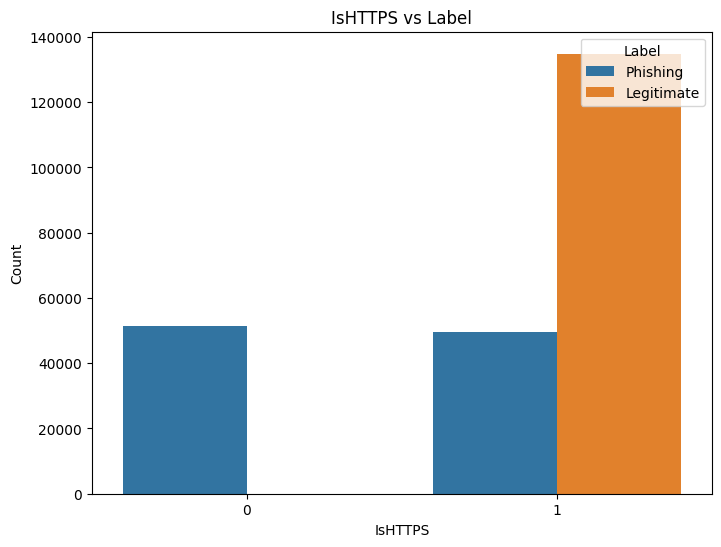

In [102]:
# Plot IsHTTPS vs Label
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='IsHTTPS', hue='label')
plt.title("IsHTTPS vs Label")
plt.xlabel("IsHTTPS")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right", labels=["Phishing", "Legitimate"])
plt.show()


In [103]:
# Store model in pickle

with open("phiuslil.random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)